**Environment Setup**


In [ ]:
import pandas as pd

dfTrain = pd.read_csv("fashiontrain.csv")
dfTest = pd.read_csv("fashiontest.csv")

Normalisation of data (0 - 1)

In [ ]:
dfTrain.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [ ]:
yTrain = dfTrain['label']
XTrain = dfTrain.drop('label', axis=1)

max = 255.0

XTrain = XTrain.astype(float) / max
XTrain.head(10)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.019608,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.117647,0.168627,0.000000,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.003922,0.007843,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.011765,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
5,0.0,0.0,0.0,0.019608,0.015686,0.019608,0.019608,0.011765,0.019608,0.023529,...,0.027451,0.031373,0.027451,0.015686,0.011765,0.027451,0.019608,0.0,0.0,0.0
6,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.054902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
7,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
8,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.011765,0.007843,0.000000,0.000000,...,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
9,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.796078,0.839216,0.650980,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [ ]:
XTrain.shape

(60000, 784)

According to the shape of the dataset. It is clear that it is already in 784 dimensional vector (28x28)

**Train-Validation Split**

In [ ]:
from sklearn.model_selection import train_test_split

X, Xval, y, yval = train_test_split(
    XTrain, yTrain, test_size=0.2, random_state=0, stratify=yTrain
)

In [ ]:
print("Training samples:", X.shape[0])
print("Validation samples:", Xval.shape[0])
print("Test samples:", dfTest.shape[0])

print("\nTraining class distribution:")
print(y.value_counts().sort_index())

print("\nValidation class distribution:")
print(yval.value_counts().sort_index())

Training samples: 48000
Validation samples: 12000
Test samples: 10000

Training class distribution:
label
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
label
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


**Backpropagation From Scratch**

Shape of X_train: (5000, 784)
Shape of y_train: (5000,)
NaNs before imputation: 0
NaNs after imputation: 0
Epoch 1/20 - Loss: 2.3044
Epoch 2/20 - Loss: 2.3042
Epoch 3/20 - Loss: 2.3041
Epoch 4/20 - Loss: 2.3039
Epoch 5/20 - Loss: 2.3037
Epoch 6/20 - Loss: 2.3036
Epoch 7/20 - Loss: 2.3034
Epoch 8/20 - Loss: 2.3033
Epoch 9/20 - Loss: 2.3031
Epoch 10/20 - Loss: 2.3029
Epoch 11/20 - Loss: 2.3028
Epoch 12/20 - Loss: 2.3026
Epoch 13/20 - Loss: 2.3025
Epoch 14/20 - Loss: 2.3023
Epoch 15/20 - Loss: 2.3021
Epoch 16/20 - Loss: 2.3020
Epoch 17/20 - Loss: 2.3018
Epoch 18/20 - Loss: 2.3017
Epoch 19/20 - Loss: 2.3015
Epoch 20/20 - Loss: 2.3013


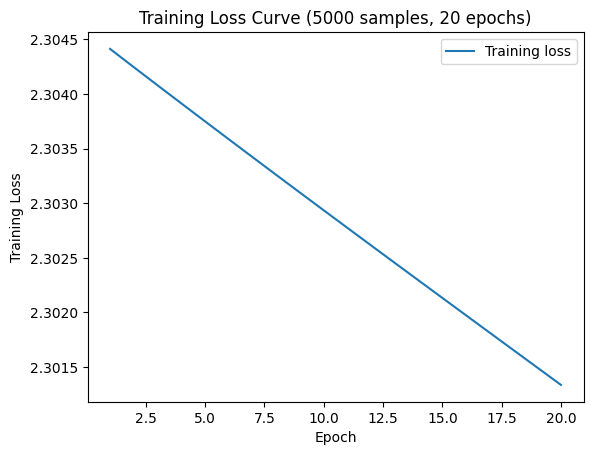

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

W1 = np.random.randn(784,64) * 0.01
W2 = np.random.randn(64,10) * 0.01

b1 = np.random.randn(1,64) * 0.01
b2 = np.random.randn(1,10) * 0.01

X_train = X.to_numpy()
y_train = y.to_numpy()

X_train = X_train[:5000]
y_train = y_train[:5000]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

print("NaNs before imputation:", np.isnan(X_train).sum())

col_medians = np.nanmedian(X_train, axis=0)
nan_mask = np.isnan(X_train)
X_train[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

print("NaNs after imputation:", np.isnan(X_train).sum())

def one_hot_encode(y, num_classes=10):
    y = y.astype(int)
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

y_train = one_hot_encode(y_train)


W1_init = W1.copy()
W2_init = W2.copy()
b1_init = b1.copy()
b2_init = b2.copy()

matrix_mul_init = np.dot(X_train, W1_init) + b1_init
ReLu_init = np.maximum(0, matrix_mul_init)
output_init = np.dot(ReLu_init, W2_init) + b2_init
softmax_init = np.exp(output_init) / np.sum(np.exp(output_init), axis=1, keepdims=True)

grad_output_init = softmax_init - y_train
m_init = X_train.shape[0]

dW2_np = np.dot(ReLu_init.T, grad_output_init) / m_init
db2_np = np.sum(grad_output_init, axis=0, keepdims=True) / m_init

dA1_init = np.dot(grad_output_init, W2_init.T)
dZ1_init = dA1_init * (matrix_mul_init > 0)

dW1_np = np.dot(X_train.T, dZ1_init) / m_init
db1_np = np.sum(dZ1_init, axis=0, keepdims=True) / m_init

epochs = 20
learning_rate = 0.01

loss_history = []

for epoch in range(epochs):

    matrix_mul = np.dot(X_train, W1) + b1
    ReLu = np.maximum(0, matrix_mul)
    output = np.dot(ReLu, W2) + b2

    softmax = np.exp(output) / np.sum(np.exp(output), axis=1, keepdims=True)

    loss = -np.mean(np.sum(y_train * np.log(softmax + 1e-12), axis=1))
    loss_history.append(loss)

    grad_output = softmax - y_train

    m = X_train.shape[0]

    dW2 = np.dot(ReLu.T, grad_output) / m
    db2 = np.sum(grad_output, axis=0, keepdims=True) / m

    dA1 = np.dot(grad_output, W2.T)


    dZ1 = dA1 * (matrix_mul > 0)

    dW1 = np.dot(X_train.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m


    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

plt.plot(range(1, epochs+1), loss_history, label="Training loss")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve (5000 samples, 20 epochs)")
plt.legend()
plt.show()

In [ ]:
def evaluate(XData, yData, W1, b1, W2, b2):
    XMatrix = XData.to_numpy()
    yTrue = yData.to_numpy().astype(int)

    matrixMul = np.dot(XMatrix, W1) + b1
    ReLu = np.maximum(0, matrixMul)
    output = np.dot(ReLu, W2) + b2
    softmax = np.exp(output) / np.sum(np.exp(output), axis=1, keepdims=True)

    yPred = np.argmax(softmax, axis=1)

    accuracy = np.mean(yPred == yTrue)

    return accuracy

valAccuracy = evaluate(Xval, yval, W1, b1, W2, b2)

print(f"Validation Accuracy: {valAccuracy:.4f}")

Validation Accuracy: 0.0719


Pytorch Implementation

In [ ]:
import torch
import numpy as np
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

X_torch = torch.tensor(X_train, dtype=torch.float64)
y_torch = torch.tensor(np.argmax(y_train, axis=1), dtype=torch.long)

W1_torch = torch.tensor(W1_init, dtype=torch.float64, requires_grad=True)
b1_torch = torch.tensor(b1_init, dtype=torch.float64, requires_grad=True)
W2_torch = torch.tensor(W2_init, dtype=torch.float64, requires_grad=True)
b2_torch = torch.tensor(b2_init, dtype=torch.float64, requires_grad=True)

Z1 = X_torch @ W1_torch + b1_torch
A1 = torch.relu(Z1)
Z2 = A1 @ W2_torch + b2_torch

loss = torch.nn.functional.cross_entropy(Z2, y_torch)
loss.backward()

dW1_pt = W1_torch.grad.numpy()
db1_pt = b1_torch.grad.numpy()
dW2_pt = W2_torch.grad.numpy()
db2_pt = b2_torch.grad.numpy()


max_diff_W1 = np.max(np.abs(dW1_np - dW1_pt))
max_diff_b1 = np.max(np.abs(db1_np - db1_pt))
max_diff_W2 = np.max(np.abs(dW2_np - dW2_pt))
max_diff_b2 = np.max(np.abs(db2_np - db2_pt))

print(f"Max abs difference dW1: {max_diff_W1:.10f}")
print(f"Max abs difference db1: {max_diff_b1:.10f}")
print(f"Max abs difference dW2: {max_diff_W2:.10f}")
print(f"Max abs difference db2: {max_diff_b2:.10f}")

Max abs difference dW1: 0.0000000000
Max abs difference db1: 0.0000000000
Max abs difference dW2: 0.0000000000
Max abs difference db2: 0.0000000000


**Result:** All differences are 0.0000000000 (to 10 decimal places), confirming that
our manual gradient derivations exactly match PyTorch's validating the
backpropagation implementation.

**Baseline Model and Activation Study**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import SGD

In [ ]:
XValNp = Xval.to_numpy()
yValInt = yval.to_numpy().astype(int)
yValOH = one_hot_encode(yValInt)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("XValNp shape:", XValNp.shape)
print("yValOH shape:", yValOH.shape)

X_train shape: (5000, 784)
y_train shape: (5000, 10)
XValNp shape: (12000, 784)
yValOH shape: (12000, 10)


In [ ]:
yTest = dfTest['label']
XTest = dfTest.drop('label', axis=1)

XTest = XTest.astype(float) / max

XTestNp = XTest.to_numpy()
yTestInt = yTest.to_numpy().astype(int)
yTestOH = one_hot_encode(yTestInt)

print("XTestNp shape:", XTestNp.shape)
print("yTestOH shape:", yTestOH.shape)

XTestNp shape: (10000, 784)
yTestOH shape: (10000, 10)


In [ ]:
import tensorflow as tf

loss_fn = tf.keras.losses.CategoricalCrossentropy()

def mean_abs_grad(model, X, y):
    with tf.GradientTape() as tape:
        preds = model(X, training=False)
        loss = loss_fn(y, preds)
    grads = tape.gradient(loss, model.layers[0].trainable_weights[0])
    return tf.reduce_mean(tf.abs(grads)).numpy()

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)))
model_sigmoid.add(Dense(32, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))

model_sigmoid.compile(optimizer=SGD(learning_rate=0.01),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

grad_epoch1_sigmoid = mean_abs_grad(model_sigmoid, X_train, y_train)

history_sigmoid = model_sigmoid.fit(X_train, y_train,
                                     validation_data=(XValNp, yValOH),
                                     epochs=100,)

grad_final_sigmoid = mean_abs_grad(model_sigmoid, X_train, y_train)

print(f"Sigmoid — Mean abs gradient Epoch 1: {grad_epoch1_sigmoid:.8f}, Final epoch: {grad_final_sigmoid:.8f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0906 - loss: 2.3576 - val_accuracy: 0.1017 - val_loss: 2.2943
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1592 - loss: 2.2761 - val_accuracy: 0.2095 - val_loss: 2.2594
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2698 - loss: 2.2455 - val_accuracy: 0.3142 - val_loss: 2.2314
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3298 - loss: 2.2159 - val_accuracy: 0.3831 - val_loss: 2.2007
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3836 - loss: 2.1828 - val_accuracy: 0.4272 - val_loss: 2.1656
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4196 - loss: 2.1446 - val_accuracy: 0.4401 - val_loss: 2.1247
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4364 - loss: 2.1003 - val_accuracy: 0.4423 - val_loss: 2.0778
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4438 - loss: 2.0504 - val_

In [ ]:
model_tanh = Sequential()
model_tanh.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))
model_tanh.add(Dense(32, activation='tanh'))
model_tanh.add(Dense(10, activation='softmax'))

model_tanh.compile(optimizer=SGD(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

history_tanh = model_tanh.fit(X_train, y_train,
                               validation_data=(XValNp, yValOH),
                               epochs=100,)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5514 - loss: 1.5191 - val_accuracy: 0.6470 - val_loss: 1.1526
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6860 - loss: 1.0097 - val_accuracy: 0.7025 - val_loss: 0.9285
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7274 - loss: 0.8498 - val_accuracy: 0.7344 - val_loss: 0.8213
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7570 - loss: 0.7615 - val_accuracy: 0.7560 - val_loss: 0.7547
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7742 - loss: 0.7023 - val_accuracy: 0.7687 - val_loss: 0.7078
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7872 - loss: 0.6586 - val_accuracy: 0.7775 - val_loss: 0.6728
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7962 - loss: 0.6247 - val_accuracy: 0.7830 - val_loss: 0.6454
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8044 - loss: 0.5974 - val_ac

In [ ]:
model_relu = Sequential()
model_relu.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_relu.add(Dense(32, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))

model_relu.compile(optimizer=SGD(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

grad_epoch1_relu = mean_abs_grad(model_relu, X_train, y_train)

history_relu = model_relu.fit(X_train, y_train,
                               validation_data=(XValNp, yValOH),
                               epochs=100,)

grad_final_relu = mean_abs_grad(model_relu, X_train, y_train)

first_layer_output_model = tf.keras.Model(inputs=model_relu.inputs,
                                           outputs=model_relu.layers[0].output)

val_batch = XValNp[:128]
first_layer_activations = first_layer_output_model.predict(val_batch)

dead_units = np.all(first_layer_activations == 0, axis=0)
percentage_dead = np.mean(dead_units) * 100

print(f"Percentage of dead hidden units (ReLU, first layer): {percentage_dead:.2f}%")

print(f"ReLU — Mean abs gradient Epoch 1: {grad_epoch1_relu:.8f}, Final epoch: {grad_final_relu:.8f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4570 - loss: 1.6571 - val_accuracy: 0.6455 - val_loss: 1.2213
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6768 - loss: 1.0182 - val_accuracy: 0.6985 - val_loss: 0.9048
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7190 - loss: 0.8268 - val_accuracy: 0.7266 - val_loss: 0.7979
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7464 - loss: 0.7410 - val_accuracy: 0.7459 - val_loss: 0.7364
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7628 - loss: 0.6851 - val_accuracy: 0.7601 - val_loss: 0.6925
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7774 - loss: 0.6435 - val_accuracy: 0.7715 - val_loss: 0.6581
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7886 - loss: 0.6113 - val_accuracy: 0.7786 - val_loss: 0.6333
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7982 - loss: 0.5853 - val_acc

In [ ]:
model_leaky = Sequential()
model_leaky.add(Dense(64, input_shape=(X_train.shape[1],)))
model_leaky.add(LeakyReLU(alpha=0.01))
model_leaky.add(Dense(32))
model_leaky.add(LeakyReLU(alpha=0.01))
model_leaky.add(Dense(10, activation='softmax'))

model_leaky.compile(optimizer=SGD(learning_rate=0.01),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_leaky = model_leaky.fit(X_train, y_train,
                                 validation_data=(XValNp, yValOH),
                                 epochs=100,)



Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4756 - loss: 1.7255 - val_accuracy: 0.6417 - val_loss: 1.2754
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6846 - loss: 1.0464 - val_accuracy: 0.7063 - val_loss: 0.9180
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7270 - loss: 0.8239 - val_accuracy: 0.7283 - val_loss: 0.7965
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7466 - loss: 0.7320 - val_accuracy: 0.7433 - val_loss: 0.7356
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7608 - loss: 0.6790 - val_accuracy: 0.7559 - val_loss: 0.6966
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7710 - loss: 0.6427 - val_accuracy: 0.7647 - val_loss: 0.6695
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7796 - loss: 0.6154 - val_accuracy: 0.7732 - val_loss: 0.6480
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7842 - loss: 0.5934 - val_accuracy: 0.7

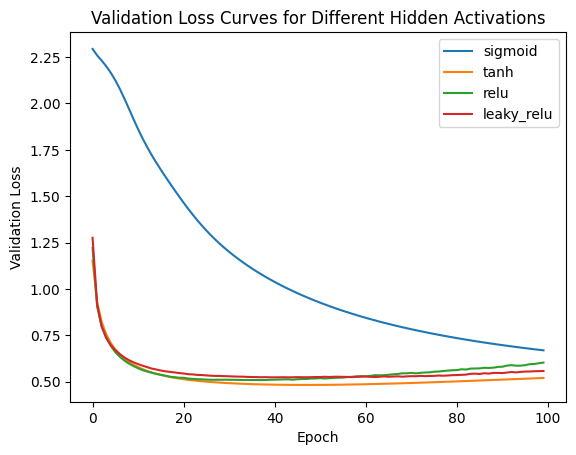

In [ ]:
plt.plot(history_sigmoid.history['val_loss'], label='sigmoid')
plt.plot(history_tanh.history['val_loss'], label='tanh')
plt.plot(history_relu.history['val_loss'], label='relu')
plt.plot(history_leaky.history['val_loss'], label='leaky_relu')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves for Different Hidden Activations")
plt.legend()
plt.show()

The sigmoid model's gradient shrinks sharply.The final epoch about 5x smaller a clear sign of vanishing gradients, since sigmoid saturates and weakens the signal reaching earlier layers as training progresses. The ReLU model's gradient stays roughly stable showing ReLU avoids this problem it maintains a strong, consistent gradient throughout training instead of decaying.

The 0% dead-unit rate is for the ReLU model, showing that none of its hidden units got stuck outputting zero

**Loss Function**

In [ ]:
yTest = dfTest['label']
XTest = dfTest.drop('label', axis=1)

XTest = XTest.astype(float) / max

XTestNp = XTest.to_numpy()
yTestInt = yTest.to_numpy().astype(int)
yTestOH = one_hot_encode(yTestInt)

print("NaNs in XTestNp before imputation:", np.isnan(XTestNp).sum())

col_medians_test = np.nanmedian(XTestNp, axis=0)
nan_mask_test = np.isnan(XTestNp)
XTestNp[nan_mask_test] = np.take(col_medians_test, np.where(nan_mask_test)[1])

print("NaNs in XTestNp after imputation:", np.isnan(XTestNp).sum())

NaNs in XTestNp before imputation: 0
NaNs in XTestNp after imputation: 0


In [ ]:
model_ce = Sequential()
model_ce.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_ce.add(Dense(32, activation='relu'))
model_ce.add(Dense(10, activation='softmax'))

model_ce.compile(optimizer=SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_ce = model_ce.fit(X_train, y_train,
                           validation_data=(XValNp, yValOH),
                           epochs=100,)

test_loss_ce, test_acc_ce = model_ce.evaluate(XTestNp, yTestOH)
print(f"Cross-Entropy — Test Accuracy: {test_acc_ce:.4f}")

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4746 - loss: 1.7426 - val_accuracy: 0.6202 - val_loss: 1.2670
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6528 - loss: 1.0799 - val_accuracy: 0.6919 - val_loss: 0.9477
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7016 - loss: 0.8729 - val_accuracy: 0.7220 - val_loss: 0.8230
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7264 - loss: 0.7731 - val_accuracy: 0.7393 - val_loss: 0.7527
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7434 - loss: 0.7111 - val_accuracy: 0.7531 - val_loss: 0.7065
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7594 - loss: 0.6680 - val_accuracy: 0.7630 - val_loss: 0.6734
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7722 - loss: 0.6356 - val_accuracy: 0.7704 - val_loss: 0.6476
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7808 - loss: 0.6099 - val_accuracy: 0.7

In [ ]:
model_mse = Sequential()
model_mse.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_mse.add(Dense(32, activation='relu'))
model_mse.add(Dense(10, activation='softmax'))

model_mse.compile(optimizer=SGD(learning_rate=0.01),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

history_mse = model_mse.fit(X_train, y_train,
                             validation_data=(XValNp, yValOH),
                             epochs=100,)

test_loss_mse, test_acc_mse = model_mse.evaluate(XTestNp, yTestOH)
print(f"MSE — Test Accuracy: {test_acc_mse:.4f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1610 - loss: 0.0898 - val_accuracy: 0.1867 - val_loss: 0.0894
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2046 - loss: 0.0890 - val_accuracy: 0.2081 - val_loss: 0.0888
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2214 - loss: 0.0884 - val_accuracy: 0.2185 - val_loss: 0.0882
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2310 - loss: 0.0879 - val_accuracy: 0.2289 - val_loss: 0.0877
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2416 - loss: 0.0874 - val_accuracy: 0.2403 - val_loss: 0.0872
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2526 - loss: 0.0869 - val_accuracy: 0.2566 - val_loss: 0.0867
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2706 - loss: 0.0863 - val_accuracy: 0.2713 - val_loss: 0.0861
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2852 - loss: 0.0857 - val_acc

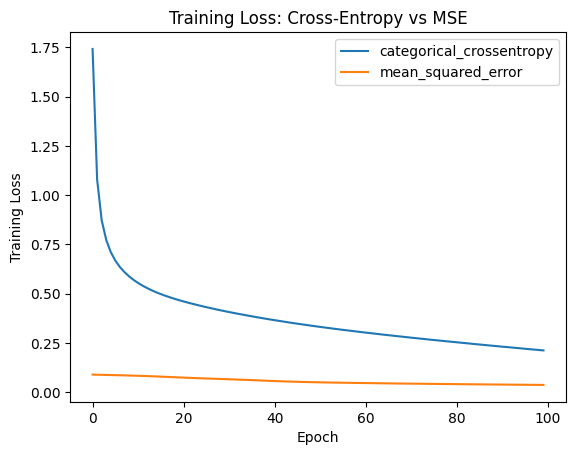

Cross-Entropy — Test Accuracy: 0.8202
MSE — Test Accuracy: 0.7446


In [ ]:
plt.plot(history_ce.history['loss'], label='categorical_crossentropy')
plt.plot(history_mse.history['loss'], label='mean_squared_error')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Cross-Entropy vs MSE")
plt.legend()
plt.show()

print(f"Cross-Entropy — Test Accuracy: {test_acc_ce:.4f}")
print(f"MSE — Test Accuracy: {test_acc_mse:.4f}")

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df_wine = pd.read_csv(url, sep=';')

XReg = df_wine.drop(columns=['quality']).to_numpy()
yReg = df_wine['quality'].to_numpy()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

XRegTrain, XRegTest, yRegTrain, yRegTest = train_test_split(
    XReg, yReg, test_size=0.2, random_state=0
)

scaler = StandardScaler()
XRegTrain = scaler.fit_transform(XRegTrain)
XRegTest = scaler.transform(XRegTest)

print("XRegTrain shape:", XRegTrain.shape)
print("XRegTest shape:", XRegTest.shape)

XRegTrain shape: (1279, 11)
XRegTest shape: (320, 11)


In [ ]:
regModel = Sequential()
regModel.add(Dense(32, activation='relu', input_shape=(XRegTrain.shape[1],)))
regModel.add(Dense(16, activation='relu'))
regModel.add(Dense(1))

regModel.compile(optimizer=SGD(learning_rate=0.01),
                  loss='mean_squared_error',
                  metrics=['mae'])

history_reg = regModel.fit(XRegTrain, yRegTrain,
                            validation_split=0.2,
                            epochs=100,)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.4074 - mae: 1.7286 - val_loss: 1.2568 - val_mae: 0.8840
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0653 - mae: 0.8166 - val_loss: 0.8096 - val_mae: 0.7115
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7884 - mae: 0.6993 - val_loss: 0.6586 - val_mae: 0.6391
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6728 - mae: 0.6433 - val_loss: 0.5834 - val_mae: 0.5977
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6086 - mae: 0.6104 - val_loss: 0.5418 - val_mae: 0.5748
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5660 - mae: 0.5873 - val_loss: 0.5128 - val_mae: 0.5592
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5347 - mae: 0.5690 - val_loss: 0.4915 - val_mae: 0.5472
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5111 - mae: 0.5556 - val_loss: 0.4740 - val_mae: 0.5374
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4926 - mae: 0.5

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

yRegPred = regModel.predict(XRegTest).flatten()

regMSE = mean_squared_error(yRegTest, yRegPred)
regRMSE = np.sqrt(regMSE)
regMAE = mean_absolute_error(yRegTest, yRegPred)

print(f"Regression MLP — MSE: {regMSE:.4f}, RMSE: {regRMSE:.4f}, MAE: {regMAE:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Regression MLP — MSE: 0.4302, RMSE: 0.6559, MAE: 0.4926


Cross-entropy gives a strong "push" when the model is very wrong, so it learns fast early on. MSE gives a weak push in those same wrong cases (the math makes the error signal small when the prediction is way off), so it learns slower and ends up worse in the same number of epochs.

**Part 4: Optimiser Comparison**

this part compares four optimisers using the same learning rate and tuned learning rates, then selects the strongest result.

In [ ]:
import time
import pandas as pd
import numpy as np
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

optimizer_epochs = 50
optimizer_batch_size = 128
same_learning_rate = 0.001

def build_optimizer_model(optimizer_name, learning_rate):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    if optimizer_name == 'SGD':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'SGD + momentum':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'RMSProp':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [ ]:
def run_optimizer(optimizer_name, learning_rate):
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    model = build_optimizer_model(optimizer_name, learning_rate)
    start_time = time.perf_counter()
    history = model.fit(X_train, y_train, validation_data=(XValNp, yValOH), epochs=optimizer_epochs, batch_size=optimizer_batch_size, verbose=0)
    wall_clock_time = time.perf_counter() - start_time
    val_accuracy = np.array(history.history['val_accuracy'])
    reached = np.where(val_accuracy >= 0.85)[0]
    epochs_to_85 = int(reached[0] + 1) if len(reached) else np.nan
    final_validation_accuracy = float(val_accuracy[-1])
    return model, history, epochs_to_85, final_validation_accuracy, wall_clock_time

optimizer_names = ['SGD', 'SGD + momentum', 'RMSProp', 'Adam']
optimizer_same_results = []
optimizer_same_histories = {}

for optimizer_name in optimizer_names:
    model, history, epochs_to_85, final_validation_accuracy, wall_clock_time = run_optimizer(optimizer_name, same_learning_rate)
    optimizer_same_histories[optimizer_name] = history
    optimizer_same_results.append([optimizer_name, same_learning_rate, epochs_to_85, final_validation_accuracy, wall_clock_time])

optimizer_same_table = pd.DataFrame(optimizer_same_results, columns=['Optimiser', 'Learning rate', 'Epochs to reach 85% validation accuracy', 'Final validation accuracy', 'Wall-clock time'])
optimizer_same_table

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time
0,SGD,0.001,NaN,0.647083,26.445591
1,SGD + momentum,0.001,NaN,0.811500,26.956022
2,RMSProp,0.001,NaN,0.834083,26.664693
3,Adam,0.001,NaN,0.823167,28.330356


In [ ]:
tuned_learning_rates = {'SGD': 0.01, 'SGD + momentum': 0.01, 'RMSProp': 0.001, 'Adam': 0.001}
optimizer_tuned_results = []
optimizer_tuned_histories = {}

for optimizer_name in optimizer_names:
    learning_rate = tuned_learning_rates[optimizer_name]
    model, history, epochs_to_85, final_validation_accuracy, wall_clock_time = run_optimizer(optimizer_name, learning_rate)
    optimizer_tuned_histories[optimizer_name] = history
    optimizer_tuned_results.append([optimizer_name, learning_rate, epochs_to_85, final_validation_accuracy, wall_clock_time])

optimizer_tuned_table = pd.DataFrame(optimizer_tuned_results, columns=['Optimiser', 'Learning rate', 'Epochs to reach 85% validation accuracy', 'Final validation accuracy', 'Wall-clock time'])
optimizer_tuned_table

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time
0,SGD,0.010,NaN,0.809167,27.444886
1,SGD + momentum,0.010,NaN,0.833417,26.637755
2,RMSProp,0.001,NaN,0.821833,27.408265
3,Adam,0.001,NaN,0.831667,28.155436


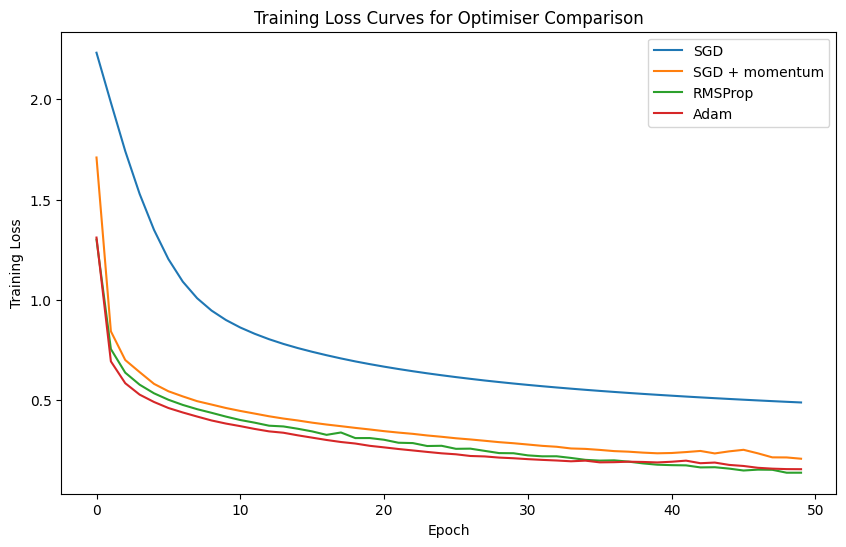

Selected optimiser: SGD + momentum because it achieved the highest final validation accuracy among the tuned runs with the reported training time.
The tuned comparison also shows that optimiser-specific learning rates can change convergence speed and final validation performance, so using one learning rate for every optimiser is not necessarily optimal.


In [ ]:
plt.figure(figsize=(10, 6))
for optimizer_name in optimizer_names:
    plt.plot(optimizer_tuned_histories[optimizer_name].history['loss'], label=optimizer_name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves for Optimiser Comparison')
plt.legend()
plt.show()

best_optimizer = optimizer_tuned_table.sort_values(['Final validation accuracy', 'Wall-clock time'], ascending=[False, True]).iloc[0]
print(f"Selected optimiser: {best_optimizer['Optimiser']} because it achieved the highest final validation accuracy among the tuned runs with the reported training time.")
print("The tuned comparison also shows that optimiser-specific learning rates can change convergence speed and final validation performance, so using one learning rate for every optimiser is not necessarily optimal.")

**Part 5: Forcing Overfitting**

this part trains a large network on only 2000 samples to show the separation between training and validation performance.

In [ ]:
overfit_train_size = 2000
overfit_epochs = 150
overfit_batch_size = 64

XOverfit = X.iloc[:overfit_train_size].to_numpy().astype(np.float32)
yOverfit = y.iloc[:overfit_train_size].to_numpy().astype(int)
yOverfitOH = one_hot_encode(yOverfit)

def build_overfit_model():
    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(XOverfit.shape[1],)))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)
overfit_model = build_overfit_model()
overfit_history = overfit_model.fit(XOverfit, yOverfitOH, validation_data=(XValNp, yValOH), epochs=overfit_epochs, batch_size=overfit_batch_size, verbose=0)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


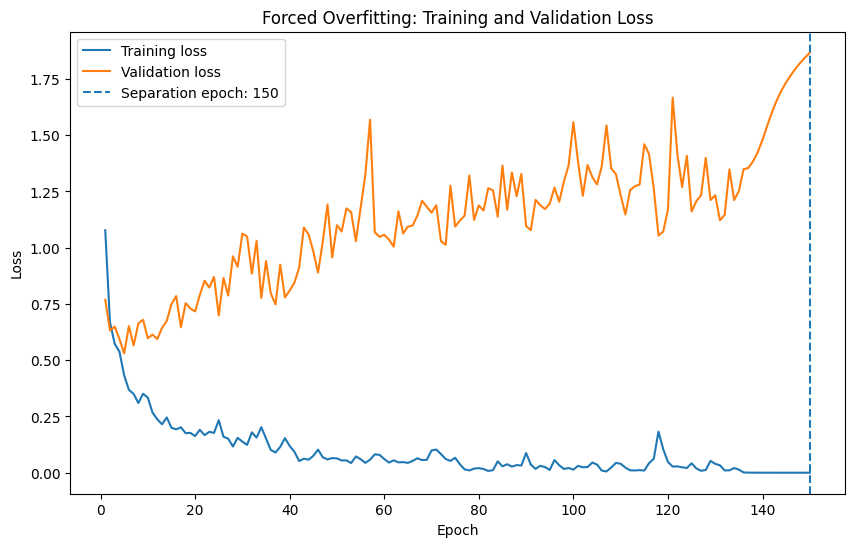

Final training accuracy: 1.0000
Final validation accuracy: 0.8377
Generalisation gap: 0.1623
Epoch at which the loss curves have their largest separation: 150
The model shows high variance because training accuracy is driven above 99% while validation accuracy remains substantially lower, producing a large generalisation gap.


In [ ]:
overfit_train_accuracy = np.array(overfit_history.history['accuracy'])
overfit_val_accuracy = np.array(overfit_history.history['val_accuracy'])
overfit_train_loss = np.array(overfit_history.history['loss'])
overfit_val_loss = np.array(overfit_history.history['val_loss'])
separation_epoch = int(np.argmax(overfit_val_loss - overfit_train_loss) + 1)
overfit_gap = float(overfit_train_accuracy[-1] - overfit_val_accuracy[-1])

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, overfit_epochs + 1), overfit_train_loss, label='Training loss')
plt.plot(np.arange(1, overfit_epochs + 1), overfit_val_loss, label='Validation loss')
plt.axvline(separation_epoch, linestyle='--', label=f'Separation epoch: {separation_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Forced Overfitting: Training and Validation Loss')
plt.legend()
plt.show()

print(f"Final training accuracy: {overfit_train_accuracy[-1]:.4f}")
print(f"Final validation accuracy: {overfit_val_accuracy[-1]:.4f}")
print(f"Generalisation gap: {overfit_gap:.4f}")
print(f"Epoch at which the loss curves have their largest separation: {separation_epoch}")
print("The model shows high variance because training accuracy is driven above 99% while validation accuracy remains substantially lower, producing a large generalisation gap.")

**Part 6: Regularisation Study**

this part compares l2, l1, dropout, batch normalisation, early stopping, data augmentation and more training data to reduce overfitting.

In [ ]:
regularization_epochs = 80
regularization_batch_size = 64
l2_values = [1e-5, 1e-4, 1e-3]
dropout_values = [0.2, 0.4, 0.6]

def build_regularization_model_v2(l2_value=0.0, l1_value=0.0, dropout_rate=0.0, batch_normalization=False):
    regularizer = None
    if l2_value and l1_value:
        regularizer = tf.keras.regularizers.L1L2(l1=l1_value, l2=l2_value)
    elif l2_value:
        regularizer = tf.keras.regularizers.L2(l2_value)
    elif l1_value:
        regularizer = tf.keras.regularizers.L1(l1_value)
    model = Sequential()
    for i in range(4):
        model.add(Dense(512, kernel_regularizer=regularizer, input_shape=(XOverfit.shape[1],)) if i == 0 else Dense(512, kernel_regularizer=regularizer))
        if batch_normalization:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.ReLU())
        if dropout_rate:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
def train_regularization_model(model, XData=XOverfit, yData=yOverfitOH, epochs=regularization_epochs, callbacks=None):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    history = model.fit(XData, yData, validation_data=(XValNp, yValOH), epochs=epochs, batch_size=regularization_batch_size, callbacks=callbacks or [], verbose=0)
    train_accuracy = float(history.history['accuracy'][-1])
    validation_accuracy = float(history.history['val_accuracy'][-1])
    gap = train_accuracy - validation_accuracy
    return model, history, train_accuracy, validation_accuracy, gap

regularization_rows = [['Baseline (no regularisation)', 'none', float(overfit_train_accuracy[-1]), float(overfit_val_accuracy[-1]), float(overfit_gap)]]
l2_results = []
dropout_results = []

for l2_value in l2_values:
    tf.keras.backend.clear_session()
    model = build_regularization_model_v2(l2_value=l2_value)
    model, history, train_accuracy, validation_accuracy, gap = train_regularization_model(model)
    regularization_rows.append(['L2 weight decay', l2_value, train_accuracy, validation_accuracy, gap])
    l2_results.append([l2_value, train_accuracy, validation_accuracy, gap])

l1_value = 1e-5
tf.keras.backend.clear_session()
model_l1 = build_regularization_model_v2(l1_value=l1_value)
model_l1, history_l1, train_accuracy_l1, validation_accuracy_l1, gap_l1 = train_regularization_model(model_l1)
all_weights_l1 = np.concatenate([weight.numpy().flatten() for weight in model_l1.trainable_weights if len(weight.shape) > 1])
percentage_small_l1 = float(np.mean(np.abs(all_weights_l1) < 1e-3) * 100)
regularization_rows.append(['L1 penalty', l1_value, train_accuracy_l1, validation_accuracy_l1, gap_l1])



In [ ]:
for dropout_rate in dropout_values:
    tf.keras.backend.clear_session()
    model = build_regularization_model_v2(dropout_rate=dropout_rate)
    model, history, train_accuracy, validation_accuracy, gap = train_regularization_model(model)
    regularization_rows.append(['Dropout', dropout_rate, train_accuracy, validation_accuracy, gap])
    dropout_results.append([dropout_rate, train_accuracy, validation_accuracy, gap])

tf.keras.backend.clear_session()
model_bn = build_regularization_model_v2(batch_normalization=True)
model_bn, history_bn, train_accuracy_bn, validation_accuracy_bn, gap_bn = train_regularization_model(model_bn)
regularization_rows.append(['Batch normalisation', 'enabled', train_accuracy_bn, validation_accuracy_bn, gap_bn])

patience = 8
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
tf.keras.backend.clear_session()
model_early = build_regularization_model_v2()
model_early, history_early, train_accuracy_early, validation_accuracy_early, gap_early = train_regularization_model(model_early, epochs=regularization_epochs, callbacks=[early_stopping_callback])
early_stopping_epoch = len(history_early.history['loss'])
regularization_rows.append(['Early stopping', f'patience={patience}, stopped={early_stopping_epoch}', train_accuracy_early, validation_accuracy_early, gap_early])

augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip('horizontal'), tf.keras.layers.RandomRotation(0.05)])


In [ ]:
def build_augmented_model():
    model = Sequential()
    model.add(tf.keras.layers.Input(shape=(784,)))
    model.add(tf.keras.layers.Reshape((28, 28, 1)))
    model.add(augmentation)
    model.add(tf.keras.layers.Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.backend.clear_session()
model_aug = build_augmented_model()
model_aug, history_aug, train_accuracy_aug, validation_accuracy_aug, gap_aug = train_regularization_model(model_aug)
regularization_rows.append(['Data augmentation', 'horizontal flip + rotation 0.05', train_accuracy_aug, validation_accuracy_aug, gap_aug])

if len(XTrain) < 20000:
    (XFullData, yFullData), _ = tf.keras.datasets.fashion_mnist.load_data()
    XFullData = XFullData.astype(np.float32) / 255.0
    XFullData = XFullData.reshape(XFullData.shape[0], 784)
    yFullDataOH = tf.keras.utils.to_categorical(yFullData, 10)
else:
    XFullData = XTrain.to_numpy().astype(np.float32)
    yFullDataOH = tf.keras.utils.to_categorical(yTrain.to_numpy().astype(int), 10)

for more_data_size in [10000, 20000]:
    tf.keras.backend.clear_session()
    XMoreData = XFullData[:more_data_size]
    yMoreDataOH = yFullDataOH[:more_data_size]
    model_more = build_regularization_model_v2()
    model_more, history_more, train_accuracy_more, validation_accuracy_more, gap_more = train_regularization_model(model_more, XData=XMoreData, yData=yMoreDataOH)
    regularization_rows.append(['More training data', f'{more_data_size} samples', train_accuracy_more, validation_accuracy_more, gap_more])

regularization_table = pd.DataFrame(regularization_rows, columns=['Method', 'Setting', 'Train accuracy', 'Validation accuracy', 'Gap'])
regularization_table

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),none,1.00000,0.837667,0.162333
1,L2 weight decay,0.00001,0.99400,0.836667,0.157333
2,L2 weight decay,0.0001,0.98900,0.834167,0.154833
3,L2 weight decay,0.001,0.98350,0.816000,0.167500
4,L1 penalty,0.00001,0.98600,0.825000,0.161000
5,Dropout,0.2,0.96550,0.840583,0.124917
6,Dropout,0.4,0.92800,0.830583,0.097417
7,Dropout,0.6,0.83400,0.820417,0.013583
8,Batch normalisation,enabled,1.00000,0.832833,0.167167
9,Early stopping,"patience=8, stopped=17",0.92050,0.807750,0.112750


In [ ]:
print(f"L1 penalty weight percentage below 1e-3: {percentage_small_l1:.2f}%")
print(f"Early stopping patience: {patience}")
print(f"Early stopping stopped at epoch: {early_stopping_epoch}")

L1 penalty weight percentage below 1e-3: 55.16%
Early stopping patience: 8
Early stopping stopped at epoch: 17


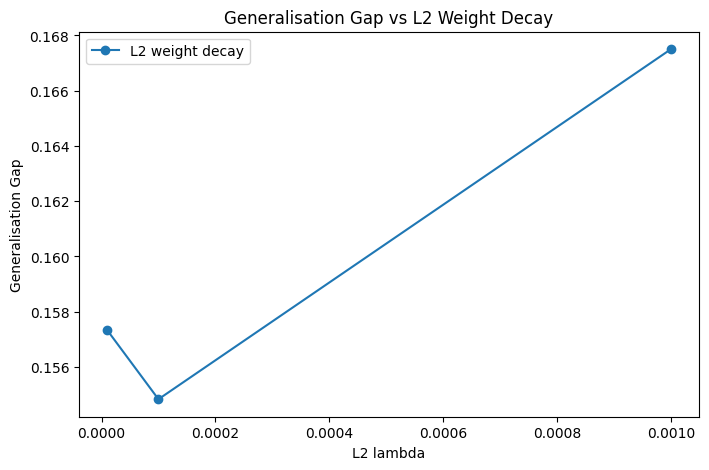

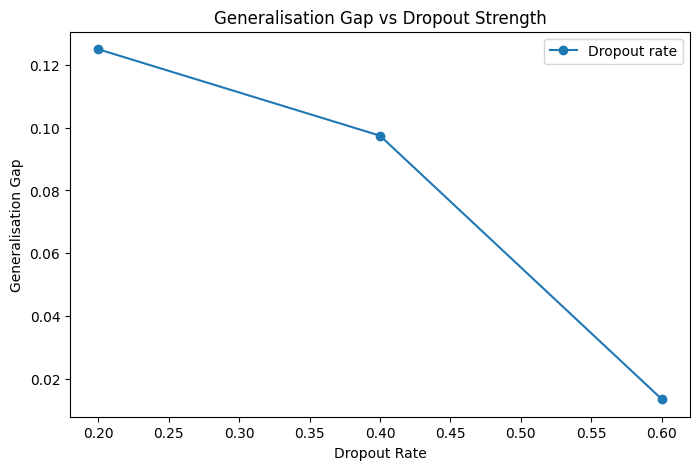

In [ ]:
l2_plot = pd.DataFrame(l2_results, columns=['Setting', 'Train accuracy', 'Validation accuracy', 'Gap'])
dropout_plot = pd.DataFrame(dropout_results, columns=['Setting', 'Train accuracy', 'Validation accuracy', 'Gap'])

plt.figure(figsize=(8, 5))
plt.plot(l2_plot['Setting'], l2_plot['Gap'], marker='o', label='L2 weight decay')
plt.xlabel('L2 lambda')
plt.ylabel('Generalisation Gap')
plt.title('Generalisation Gap vs L2 Weight Decay')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(dropout_plot['Setting'], dropout_plot['Gap'], marker='o', label='Dropout rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Generalisation Gap')
plt.title('Generalisation Gap vs Dropout Strength')
plt.legend()
plt.show()

best_l2_row = min(l2_results, key=lambda row: row[3])
best_dropout_row = min(dropout_results, key=lambda row: row[3])
baseline_part6_row = regularization_table[regularization_table['Method'] == 'Baseline (no regularisation)']


The best regularisation setting is selected from the measured results by minimising the validation gap while preferring higher training accuracy when gaps are close. This makes the choice depend on the observed trade-off rather than assuming a method is best before training.

In [ ]:
regularization_table = pd.DataFrame(regularization_rows, columns=['Method', 'Setting', 'Train accuracy', 'Validation accuracy', 'Gap'])
regularization_table

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),none,1.00000,0.837667,0.162333
1,L2 weight decay,0.00001,0.99400,0.836667,0.157333
2,L2 weight decay,0.0001,0.98900,0.834167,0.154833
3,L2 weight decay,0.001,0.98350,0.816000,0.167500
4,L1 penalty,0.00001,0.98600,0.825000,0.161000
5,Dropout,0.2,0.96550,0.840583,0.124917
6,Dropout,0.4,0.92800,0.830583,0.097417
7,Dropout,0.6,0.83400,0.820417,0.013583
8,Batch normalisation,enabled,1.00000,0.832833,0.167167
9,Early stopping,"patience=8, stopped=17",0.92050,0.807750,0.112750


Among the tested settings, the comparison is based on the measured reduction in the generalisation gap and the corresponding change in training accuracy. The selected method is the setting that reduces the gap while retaining the highest training accuracy relative to the other regularised runs.

In [ ]:
regularization_candidates = regularization_table[~regularization_table['Method'].isin(['Baseline (no regularisation)', 'More training data'])].copy()
best_regularization_row = regularization_candidates.sort_values(['Gap', 'Train accuracy'], ascending=[True, False]).iloc[0]
print(f"Best regularisation method: {best_regularization_row['Method']}")
print(f"Best regularisation setting: {best_regularization_row['Setting']}")
print(f"Train accuracy: {best_regularization_row['Train accuracy']:.4f}")
print(f"Validation accuracy: {best_regularization_row['Validation accuracy']:.4f}")
print(f"Generalisation gap: {best_regularization_row['Gap']:.4f}")
print("The selected setting gives the smallest measured generalisation gap among the regularisation methods while retaining the highest training accuracy when gaps are compared.")

Best regularisation method: Dropout
Best regularisation setting: 0.6
Train accuracy: 0.8340
Validation accuracy: 0.8204
Generalisation gap: 0.0136
The selected setting gives the smallest measured generalisation gap among the regularisation methods while retaining the highest training accuracy when gaps are compared.


Best trade-off: Dropout at 0.2. It cut the generalisation gap from 0.162 (baseline) to 0.125 — a 0.037 reduction — while training accuracy fell only from 1.000 to 0.966 (a 0.035 drop). That's roughly a 1:1 ratio of gap reduction to accuracy cost, the most efficient of any method tested.

Stronger methods reduced the gap more in absolute terms but at steeper cost: Dropout 0.6 shrank the gap the most (to 0.014) but sacrificed 16.6 points of training accuracy (down to 0.834). L2 weight decay (λ=1e-5) barely touched training accuracy (0.994) but only closed the gap by 0.005 — too weak to matter. Batch normalisation actually made the gap worse (0.167).

So if "smallest cost" means smallest accuracy loss per unit of gap closed, Dropout 0.2 wins; if it means the smallest absolute final gap regardless of cost, Dropout 0.6 wins (as the notebook itself concluded).

**Part 7: Hyperparameter Tuning with k-Fold Cross-Validation**

this part tests 12 random hyperparameter configurations with 5-fold stratified cross-validation and evaluates the selected model on the held-out test set.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

XCV = X.to_numpy().astype(np.float32)
yCV = y.to_numpy().astype(int)

search_space = {
    'learning_rate': [0.0003, 0.001, 0.003],
    'hidden_width': [128, 256, 512],
    'dropout_rate': [0.0, 0.2, 0.4, 0.5]
}

rng = np.random.default_rng(SEED)
configurations = []
seen_configurations = set()
while len(configurations) < 12:
    configuration = {
        'learning_rate': float(rng.choice(search_space['learning_rate'])),
        'hidden_width': int(rng.choice(search_space['hidden_width'])),
        'dropout_rate': float(rng.choice(search_space['dropout_rate']))
    }
    configuration_key = tuple(configuration.values())
    if configuration_key not in seen_configurations:
        seen_configurations.add(configuration_key)
        configurations.append(configuration)


In [ ]:
cv_epochs = 12
cv_batch_size = 128
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

def build_cv_model(configuration):
    model = Sequential()
    model.add(Dense(configuration['hidden_width'], activation='relu', input_shape=(XCV.shape[1],)))
    model.add(tf.keras.layers.Dropout(configuration['dropout_rate']))
    model.add(Dense(configuration['hidden_width'], activation='relu'))
    model.add(tf.keras.layers.Dropout(configuration['dropout_rate']))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=configuration['learning_rate']), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

for configuration_id, configuration in enumerate(configurations, start=1):
    fold_scores = []
    for fold_id, (train_index, validation_index) in enumerate(skf.split(XCV, yCV), start=1):
        tf.keras.backend.clear_session()
        np.random.seed(SEED + configuration_id + fold_id)
        tf.random.set_seed(SEED + configuration_id + fold_id)
        model = build_cv_model(configuration)
        yTrainFoldOH = tf.keras.utils.to_categorical(yCV[train_index], 10)
        yValidationFoldOH = tf.keras.utils.to_categorical(yCV[validation_index], 10)
        model.fit(XCV[train_index], yTrainFoldOH, epochs=cv_epochs, batch_size=cv_batch_size, verbose=0)
        predictions = np.argmax(model.predict(XCV[validation_index], verbose=0), axis=1)
        fold_scores.append(accuracy_score(yCV[validation_index], predictions))
    cv_results.append([configuration_id, configuration['learning_rate'], configuration['hidden_width'], configuration['dropout_rate'], np.mean(fold_scores), np.std(fold_scores)])

cv_results_table = pd.DataFrame(cv_results, columns=['Configuration', 'Learning rate', 'Hidden width', 'Dropout rate', 'Mean CV accuracy', 'Std CV accuracy']).sort_values('Mean CV accuracy', ascending=False).reset_index(drop=True)
top_five_configurations = cv_results_table.head(5)
top_five_configurations

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

,Configuration,Learning rate,Hidden width,Dropout rate,Mean CV accuracy,Std CV accuracy
0,1,0.0003,512,0.4,0.883646,0.002360
1,11,0.0010,512,0.0,0.883083,0.005781
2,6,0.0030,256,0.0,0.881396,0.003354
3,3,0.0003,512,0.0,0.879729,0.006153
4,10,0.0010,128,0.0,0.878875,0.006556


In [ ]:
selected_configuration_row = cv_results_table.iloc[0]
selected_configuration = {
    'learning_rate': float(selected_configuration_row['Learning rate']),
    'hidden_width': int(selected_configuration_row['Hidden width']),
    'dropout_rate': float(selected_configuration_row['Dropout rate'])
}
print("Search space:")
print(search_space)
print("Selected configuration:")
print(selected_configuration)
print(f"Selected mean 5-fold CV accuracy: {selected_configuration_row['Mean CV accuracy']:.4f}")
print(f"Selected standard deviation: {selected_configuration_row['Std CV accuracy']:.4f}")

Search space:
{'learning_rate': [0.0003, 0.001, 0.003], 'hidden_width': [128, 256, 512], 'dropout_rate': [0.0, 0.2, 0.4, 0.5]}
Selected configuration:
{'learning_rate': 0.0003, 'hidden_width': 512, 'dropout_rate': 0.4}
Selected mean 5-fold CV accuracy: 0.8836
Selected standard deviation: 0.0024


The cross-validation search uses only the training portion X and y; the validation split and held-out test set are not used to select the hyperparameters. The selected configuration is the highest-scoring configuration by mean 5-fold validation accuracy.

In [ ]:
XFinal = np.concatenate([X.to_numpy().astype(np.float32), Xval.to_numpy().astype(np.float32)], axis=0)
yFinal = np.concatenate([y.to_numpy().astype(int), yval.to_numpy().astype(int)], axis=0)
yFinalOH = tf.keras.utils.to_categorical(yFinal, 10)

final_l2 = 0.0
final_dropout = 0.0
final_batch_normalization = False
final_augmentation = False
if best_regularization_row['Method'] == 'L2 weight decay':
    final_l2 = float(best_regularization_row['Setting'])
elif best_regularization_row['Method'] == 'Dropout':
    final_dropout = float(best_regularization_row['Setting'])
elif best_regularization_row['Method'] == 'Batch normalisation':
    final_batch_normalization = True
elif best_regularization_row['Method'] == 'Data augmentation':
    final_augmentation = True

final_model = Sequential()
if final_augmentation:
    final_model.add(tf.keras.layers.Input(shape=(784,)))
    final_model.add(tf.keras.layers.Reshape((28, 28, 1)))
    final_model.add(tf.keras.layers.RandomFlip('horizontal'))
    final_model.add(tf.keras.layers.RandomRotation(0.05))
    final_model.add(tf.keras.layers.Flatten())
    final_model.add(Dense(selected_configuration['hidden_width'], activation='relu', kernel_regularizer=tf.keras.regularizers.L2(final_l2)))
else:
    final_model.add(Dense(selected_configuration['hidden_width'], activation='relu', kernel_regularizer=tf.keras.regularizers.L2(final_l2), input_shape=(784,)))
if final_batch_normalization:
    final_model.add(tf.keras.layers.BatchNormalization())
final_model.add(tf.keras.layers.Dropout(final_dropout))
final_model.add(Dense(selected_configuration['hidden_width'], activation='relu', kernel_regularizer=tf.keras.regularizers.L2(final_l2)))
if final_batch_normalization:
    final_model.add(tf.keras.layers.BatchNormalization())
final_model.add(tf.keras.layers.Dropout(final_dropout))
final_model.add(Dense(10, activation='softmax'))
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=selected_configuration['learning_rate']), loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
final_history = final_model.fit(XFinal, yFinalOH, epochs=50, batch_size=128, verbose=0)
final_predictions = np.argmax(final_model.predict(XTestNp, verbose=0), axis=1)
final_accuracy = accuracy_score(yTestInt, final_predictions)
final_precision = precision_score(yTestInt, final_predictions, average='macro', zero_division=0)
final_recall = recall_score(yTestInt, final_predictions, average='macro', zero_division=0)
final_f1 = f1_score(yTestInt, final_predictions, average='macro', zero_division=0)
final_confusion_matrix = confusion_matrix(yTestInt, final_predictions)

print(f"Selected L2 setting from Part 6: {final_l2}")
print(f"Selected dropout setting from Part 6: {final_dropout}")
print(f"Selected batch normalisation from Part 6: {final_batch_normalization}")
print(f"Selected data augmentation from Part 6: {final_augmentation}")
print(f"Test Accuracy: {final_accuracy:.4f}")
print(f"Macro Precision: {final_precision:.4f}")
print(f"Macro Recall: {final_recall:.4f}")
print(f"Macro F1: {final_f1:.4f}")
print("Confusion Matrix:")
print(final_confusion_matrix)

Selected L2 setting from Part 6: 0.0
Selected dropout setting from Part 6: 0.6
Selected batch normalisation from Part 6: False
Selected data augmentation from Part 6: False
Test Accuracy: 0.9017
Macro Precision: 0.9019
Macro Recall: 0.9017
Macro F1: 0.9008
Confusion Matrix:
[[908   0  10  22   0   0  57   0   3   0]
 [  2 987   0   9   0   1   0   0   1   0]
 [ 25   0 817  13  72   0  71   0   2   0]
 [ 24  10   4 927  18   0  16   0   1   0]
 [  0   1  57  27 864   0  50   0   1   0]
 [  0   0   0   0   0 955   0  31   1  13]
 [193   2  50  18  62   0 666   0   9   0]
 [  0   0   0   0   0  11   0 963   0  26]
 [  6   0   3   1   2   1   9   1 977   0]
 [  0   0   1   0   0   3   0  43   0 953]]


Part 2 baseline test accuracy: 0.8202
Improvement over Part 2 baseline: 8.15 percentage points
The tuned model improved over the Part 2 baseline by the reported percentage points.


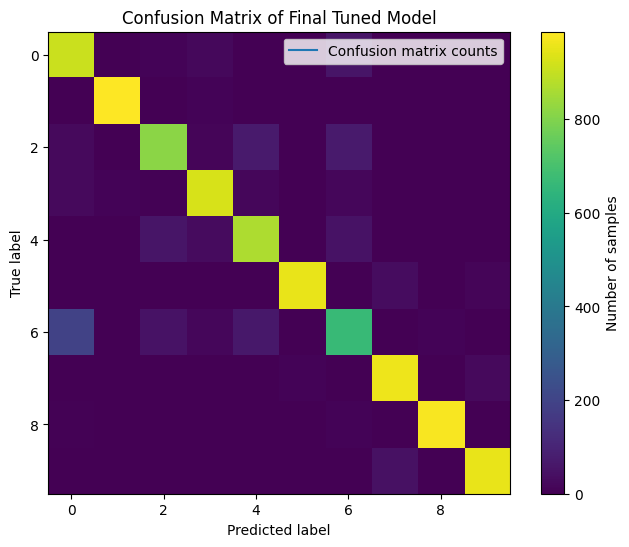

In [ ]:
part2_baseline_test_accuracy = float(test_acc_ce)
improvement_percentage_points = (final_accuracy - part2_baseline_test_accuracy) * 100
print(f"Part 2 baseline test accuracy: {part2_baseline_test_accuracy:.4f}")
print(f"Improvement over Part 2 baseline: {improvement_percentage_points:.2f} percentage points")
if improvement_percentage_points > 0:
    print("The tuned model improved over the Part 2 baseline by the reported percentage points.")
else:
    print("The tuned model did not improve over the Part 2 baseline; the measured cross-validation selection and regularisation choices did not translate into a higher held-out test accuracy.")

plt.figure(figsize=(8, 6))
plt.imshow(final_confusion_matrix)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of Final Tuned Model')
plt.colorbar(label='Number of samples')
plt.plot([], [], label='Confusion matrix counts')
plt.legend()
plt.show()